# Single-unit incrementality walkthrough

One treated unit, several treatment windows, start to finish: generate a dataset
with a known effect, estimate the lift, check the model, then translate the result
into a media-buying number.

**The method.** A counterfactual model is fit on the *untreated* buckets of a time
series and used to predict what the metric would have been inside each declared
treatment window. The gap between what happened and that prediction is the
incremental effect. Window-level ratios are aggregated, and resampling those
windows gives an interval.

**Why the data is synthetic.** The effect here is *planted*, so there is a known
answer to check against. On live data there is none — you can only ever ask whether
the model predicts untreated periods well, which is what the diagnostics section
does. Validating the harness against a plausible-looking answer would prove nothing,
so it is validated against a known one.

In [1]:
# On Colab only: install the published package. Locally, `uv sync` has already done it.
# Called through subprocess rather than a `!pip` magic so that the paired .py file
# stays valid Python.
import importlib.util
import subprocess
import sys

if "google.colab" in sys.modules and importlib.util.find_spec("arjentic") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "arjentic-incrementality"],
        check=True,
    )

In [2]:
# Prophet prints a banner on import and its sampler narrates every fit, neither of
# which belongs in a report. Absorb the banner here so the import below is quiet.
import contextlib
import io
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").disabled = True
with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
    import prophet  # noqa: F401

In [3]:
import dataclasses

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.transforms as transforms
import pandas as pd

from arjentic.incrementality import BaselineState, RunConfig, generate, run
from arjentic.incrementality.contracts import Role, validate
from arjentic.incrementality.diagnostics import backtest
from arjentic.incrementality.estimate import label_roles
from arjentic.incrementality.models import get_model

pd.set_option("display.float_format", "{:,.4f}".format)

In [4]:
# Chart styling. One place, so every figure reads as part of the same set.
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
SECONDARY = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
ACTUAL = "#2a78d6"  # categorical slot 1
COUNTERFACTUAL = "#eb6834"  # categorical slot 2

plt.rcParams.update(
    {
        "figure.figsize": (11, 4),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.labelcolor": SECONDARY,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titlelocation": "left",
        "axes.titlepad": 12,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": SECONDARY,
        "ytick.labelcolor": SECONDARY,
        "font.size": 10,
        "legend.frameon": False,
        "lines.linewidth": 1.6,
    }
)


def style(ax, title=None, ylabel=None):
    """Hairline recessive chrome: no top/right spines, horizontal grid only."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.8)
    ax.grid(axis="x", visible=False)
    if title:
        ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    return ax

## 1. The dataset

Hourly buckets over 90 days: a trend, weekly and daily seasonality, multiplicative
noise, and a **20% effect planted inside four scattered treatment windows**. Read it
as clicks on a paid-media channel that was switched on for four short bursts.

In [5]:
df, windows, truth = generate()

print(f"observations : {len(df):,} hourly buckets")
print(f"span         : {df['timestamp'].min()} -> {df['timestamp'].max()}")
print(f"planted effect: {truth['effect_size']:+.0%}")
windows

observations : 2,160 hourly buckets
span         : 2024-01-01 00:00:00+00:00 -> 2024-03-30 23:00:00+00:00
planted effect: +20%


,window_id,start,end
0,w0,2024-01-24 04:00:00+00:00,2024-01-24 10:00:00+00:00
1,w1,2024-02-07 14:00:00+00:00,2024-02-07 20:00:00+00:00
2,w2,2024-02-22 00:00:00+00:00,2024-02-22 06:00:00+00:00
3,w3,2024-03-07 10:00:00+00:00,2024-03-07 16:00:00+00:00


The data contract is enforced before anything else touches it — dtypes, nulls,
duplicate buckets, regular spacing, timezone-awareness, and that every declared
window actually covers observations. It returns both frames sorted into canonical
order, which is what lets everything downstream count buckets positionally.

In [6]:
observations, treatment_windows = validate(df, windows)
observations.head(3)

,unit_id,timestamp,value
0,unit_0,2024-01-01 00:00:00+00:00,70.6399
1,unit_0,2024-01-01 01:00:00+00:00,68.8064
2,unit_0,2024-01-01 02:00:00+00:00,75.6857


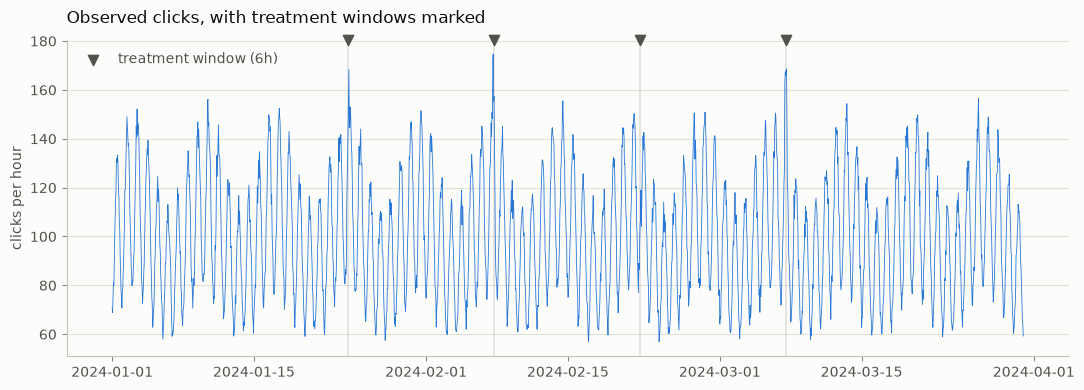

In [7]:
fig, ax = plt.subplots()
ax.plot(observations["timestamp"], observations["value"], color=ACTUAL, linewidth=0.6)
for _, window in treatment_windows.iterrows():
    ax.axvspan(window["start"], window["end"], color=MUTED, alpha=0.20, linewidth=0)

# Six hours is a quarter of a percent of this axis, so a shaded band alone is
# indistinguishable from a gridline. Mark each window on the top edge instead.
midpoints = treatment_windows["start"] + (
    treatment_windows["end"] - treatment_windows["start"]
) / 2
ax.scatter(
    midpoints,
    [1.0] * len(midpoints),
    marker="v",
    s=55,
    color=SECONDARY,
    transform=transforms.blended_transform_factory(ax.transData, ax.transAxes),
    clip_on=False,
    zorder=5,
    label="treatment window (6h)",
)

ax.legend(loc="upper left", labelcolor=SECONDARY)
style(ax, "Observed clicks, with treatment windows marked", "clicks per hour")
fig.tight_layout()

The windows are only hours long against 90 days of data, so the effect is invisible
at this zoom. That is the normal condition — it is why the estimate needs a model
rather than an eyeball.

## 2. The experiment, declared up front

Every choice that shapes the answer is stated before the answer is computed, and the
result carries this object so a run describes itself.

Two fields do the most work:

- **`baseline_state`** — was the treatment *on* or *off* during the baseline period?
  Here the media ran only inside the windows, so the baseline is `UNTREATED`. This
  determines the sign of the estimate, so it is declared rather than inferred.
  A positive result always means the treatment increased the metric.
- **`washout_before` / `washout_after`** — buckets adjacent to each window are
  discarded from both the fit and the score, because carryover means they are
  neither cleanly treated nor cleanly untreated. There is deliberately no default;
  an unstated washout is a modelling assumption made by accident.

In [8]:
# Model parameters belong to the backend that reads them, so they are declared per
# backend rather than shared. Prophet's seasonality is pinned explicitly instead of
# left to its own detection, which depends on how long the series happens to be.
MODEL_PARAMS = {
    "prophet": {"daily_seasonality": True, "weekly_seasonality": True},
    "naive": {},
}

config = RunConfig(
    unit_id="unit_0",
    baseline_state=BaselineState.UNTREATED,
    washout_before=3,
    washout_after=6,
    primary_model="prophet",
    model_params=MODEL_PARAMS["prophet"],
    backtest_holdout_buckets=168,
    bootstrap_seed=20260907,
    bootstrap_resamples=2000,
)


def config_for(model_name):
    """The same declared experiment, run through a different backend."""
    return dataclasses.replace(
        config, primary_model=model_name, model_params=MODEL_PARAMS[model_name]
    )


config

RunConfig(unit_id='unit_0', baseline_state=<BaselineState.UNTREATED: 'untreated'>, washout_before=3, washout_after=6, primary_model='prophet', backtest_holdout_buckets=168, model_params={'daily_seasonality': True, 'weekly_seasonality': True}, bootstrap_seed=20260907, bootstrap_resamples=2000)

Washout is resolved once, upstream, into a role per bucket. Nothing downstream needs
to know washout exists — the model fits `baseline`, the estimator scores `window`,
and `washout` is simply never selected.

In [9]:
labeled = label_roles(
    observations,
    treatment_windows,
    washout_before=config.washout_before,
    washout_after=config.washout_after,
)
labeled["role"].value_counts().rename("buckets").to_frame()

,buckets
role,
baseline,2100
washout,36
window,24


## 3. The estimate

In [10]:
result = run(df, windows, config)
result.per_window

,window_id,actual,counterfactual,buckets,lift
0,w0,840.1479,704.7847,6,0.1921
1,w1,918.4356,740.5169,6,0.2403
2,w2,603.1572,534.2269,6,0.1290
3,w3,982.3025,794.9798,6,0.2356


`actual` and `counterfactual` are summed over each window's buckets before dividing,
rather than averaging per-bucket ratios, which would be unstable wherever the
counterfactual is small.

In [11]:
print(f"planted effect        : {truth['effect_size']:+.2%}")
print()
print(f"pooled lift           : {result.pooled_lift:+.2%}")
print(f"mean of window ratios : {result.mean_of_ratios_lift:+.2%}")
print(f"95% interval          : [{result.ci_lower:+.2%}, {result.ci_upper:+.2%}]")
print(f"interval from         : {result.ci_method}")
print(f"model                 : {result.model_name}")

planted effect        : +20.00%

pooled lift           : +20.53%
mean of window ratios : +19.92%
95% interval          : [+16.42%, +23.90%]
interval from         : bootstrap
model                 : prophet


**Pooled** weights each window by its volume; **mean-of-ratios** weights each window
equally. Both are reported and neither is flagged as correct — a wide gap between
them means the windows disagree, and that is something to look at rather than
something to resolve automatically. The interval brackets the pooled figure, since
that is the volume-weighted quantity the media translation below depends on.

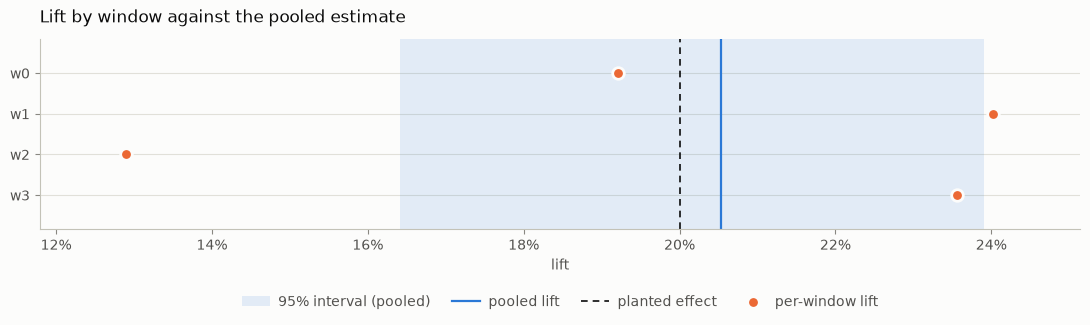

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.6))
per_window = result.per_window

ax.axvspan(
    result.ci_lower,
    result.ci_upper,
    color=ACTUAL,
    alpha=0.12,
    linewidth=0,
    label="95% interval (pooled)",
)
ax.axvline(result.pooled_lift, color=ACTUAL, linewidth=1.6, label="pooled lift")
ax.axvline(
    truth["effect_size"],
    color=INK,
    linewidth=1.2,
    linestyle=(0, (4, 3)),
    label="planted effect",
)
ax.scatter(
    per_window["lift"],
    per_window["window_id"],
    s=70,
    color=COUNTERFACTUAL,
    zorder=3,
    edgecolor=SURFACE,
    linewidth=2,
    label="per-window lift",
)

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.invert_yaxis()
ax.margins(x=0.10, y=0.28)
# Below the axis, not inside it: the per-window points reach both edges.
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncols=4,
    labelcolor=SECONDARY,
    handletextpad=0.6,
    columnspacing=1.6,
)
style(ax, "Lift by window against the pooled estimate", None)
ax.set_xlabel("lift")
fig.tight_layout()

### What the model actually predicted

Zooming into one window shows the mechanism: the counterfactual and its prediction
interval are what the model expected absent treatment, and the gap above it is the
incremental volume being counted.

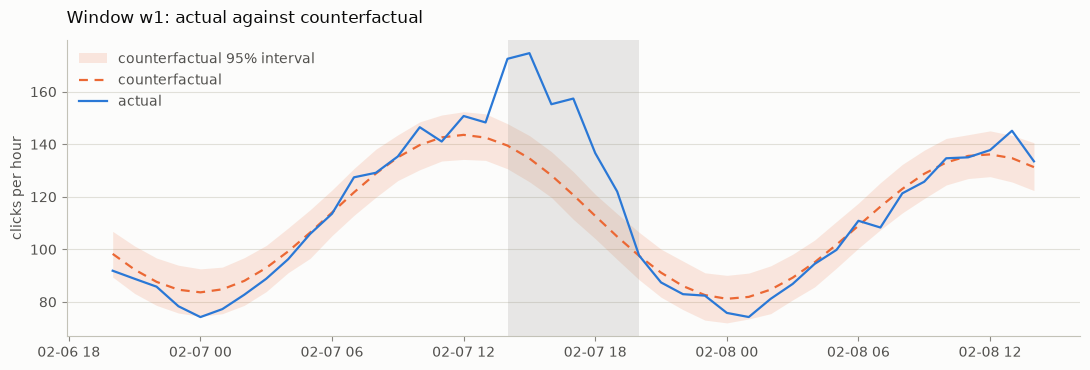

In [13]:
window = treatment_windows.iloc[1]
scored = labeled[labeled["window_id"] == window["window_id"]]

model = get_model(config.primary_model, **config.model_params)
model.fit(labeled[labeled["role"] == Role.BASELINE])

context = labeled[
    (labeled["timestamp"] >= window["start"] - pd.Timedelta(hours=18))
    & (labeled["timestamp"] <= window["end"] + pd.Timedelta(hours=18))
]
forecast = model.predict(context["timestamp"])

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.fill_between(
    forecast["timestamp"],
    forecast["lower"],
    forecast["upper"],
    color=COUNTERFACTUAL,
    alpha=0.15,
    linewidth=0,
    label="counterfactual 95% interval",
)
ax.plot(
    forecast["timestamp"],
    forecast["expected"],
    color=COUNTERFACTUAL,
    linestyle=(0, (4, 3)),
    label="counterfactual",
)
ax.plot(context["timestamp"], context["value"], color=ACTUAL, label="actual")
ax.axvspan(window["start"], window["end"], color=MUTED, alpha=0.18, linewidth=0)

ax.legend(loc="upper left", labelcolor=SECONDARY)
style(ax, f"Window {window['window_id']}: actual against counterfactual", "clicks per hour")
fig.tight_layout()

## 4. Checking the model, separately from the estimate

The estimate rests entirely on the counterfactual being credible. The backtest holds
out a contiguous slice of *baseline* buckets, refits without them, and scores the
prediction — the only check available on live data, where nothing is planted.

The slice comes from the **middle** rather than the end. The estimator fits on
baseline either side of each window and predicts the gap between, so it interpolates;
a tail holdout would measure extrapolation and understate the model at a task it
never performs.

In [14]:
rows = []
for model_name in ("naive", "prophet"):
    diagnostic = backtest(df, windows, config_for(model_name))
    rows.append(
        {
            "model": diagnostic.model_name,
            "coverage": diagnostic.coverage,
            "nominal": diagnostic.nominal_coverage,
            "MAE": diagnostic.mae,
            "bias": diagnostic.bias,
            "relative bias": diagnostic.relative_bias,
        }
    )
pd.DataFrame(rows).set_index("model")

,coverage,nominal,MAE,bias,relative bias
model,,,,,
naive,0.9107,0.9500,2.2372,-0.1905,-0.0019
prophet,0.9643,0.9500,3.5965,-0.1265,-0.0013


Three numbers, three different jobs:

- **Coverage** against nominal says whether the prediction interval is honest. It
  matters most for single-window designs, whose reported interval is derived from
  these bounds directly.
- **MAE** is the size of the typical error.
- **Relative bias** is the one that maps onto the answer. A counterfactual running
  low by 2% inflates the lift estimate by roughly 2 percentage points, near enough
  one-for-one. MAE cannot distinguish that from harmless symmetric noise, which
  averages out over a window — so bias is reported next to it rather than folded in.

`naive` is a day-of-week × hour-of-day mean. It exists partly to keep the model
interface honest and partly as a sanity comparator: if a sophisticated backend cannot
beat a groupby, that is worth knowing before it is quoted to anyone.

In [15]:
comparison = []
for model_name in ("naive", "prophet"):
    alternative = run(df, windows, config_for(model_name))
    comparison.append(
        {
            "model": alternative.model_name,
            "pooled lift": alternative.pooled_lift,
            "CI low": alternative.ci_lower,
            "CI high": alternative.ci_upper,
            "width": alternative.ci_upper - alternative.ci_lower,
        }
    )
pd.DataFrame(comparison).set_index("model")

,pooled lift,CI low,CI high,width
model,,,,
naive,0.2054,0.1945,0.2150,0.0205
prophet,0.2053,0.1642,0.2390,0.0749


Two methods with almost nothing in common landing on the same answer is the strongest
evidence available that the pipeline produced it, rather than one model's quirk.
Prophet's interval is the wider of the two — its per-window counterfactuals disagree
with each other more, and resampling windows is what surfaces that.

## 5. Translating into a media number

This section is presentation, not framework. It stays in the notebook because the
right business metric differs per client, and burying an assumption like the spend
figure inside a library is how it stops getting questioned.

Suppose the four bursts cost **$18,000** in media. The platform would report a cost
per click against *every* click recorded while the campaign ran. Most of those clicks
would have happened anyway — that is exactly what the counterfactual estimates.

In [16]:
MEDIA_SPEND = 18_000.0

clicks_during = result.per_window["actual"].sum()
counterfactual_clicks = result.per_window["counterfactual"].sum()
incremental = clicks_during - counterfactual_clicks

reported_cpc = MEDIA_SPEND / clicks_during
effective_cpc = MEDIA_SPEND / incremental

# Lift maps to incremental volume, so the interval carries straight through --
# inverted, because a higher lift means a cheaper incremental click.
effective_cpc_low = MEDIA_SPEND / (result.ci_upper * counterfactual_clicks)
effective_cpc_high = MEDIA_SPEND / (result.ci_lower * counterfactual_clicks)

print(f"media spend                : ${MEDIA_SPEND:,.0f}")
print(f"clicks while media ran     : {clicks_during:,.0f}")
print(f"of which incremental       : {incremental:,.0f}  ({incremental / clicks_during:.1%})")
print()
print(f"reported CPC               : ${reported_cpc:,.2f}")
print(f"effective CPC              : ${effective_cpc:,.2f}")
print(f"  95% interval             : ${effective_cpc_low:,.2f} - ${effective_cpc_high:,.2f}")
print()
print(f"reported CPC understates cost per incremental click by {effective_cpc / reported_cpc:.1f}x")

media spend                : $18,000
clicks while media ran     : 3,344
of which incremental       : 570  (17.0%)

reported CPC               : $5.38
effective CPC              : $31.60
  95% interval             : $27.14 - $39.52

reported CPC understates cost per incremental click by 5.9x


That multiple is the whole argument for running the test. Judged on reported CPC the
channel looks several times more efficient than it is, because the denominator counts
clicks the business would have received for free. The effective figure is the one to
compare against a margin or a target cost per acquisition.

## 6. How to read this, and where it stops

**The interval is optimistic.** Measured across window counts from 2 to 12, the
percentile bootstrap contained the true effect 73–87% of the time against a nominal
95%, and more windows did not fix it — the interval narrows roughly with the square
root of the window count while systematic forecast misfit does not shrink. With only
two windows it can collapse to almost nothing. Read these bounds as indicative, and
treat a result whose interval barely excludes zero as unresolved.

**A single short window is fragile.** Holding a design fixed and moving only *where*
one 6-hour window falls moved the error from +8.1 to −6.0 percentage points, with
barely a point of scatter within each position. That is local seasonality misfit, not
noise, and one short window has nothing to average it against. Several scattered
windows is not a nicety; it is what makes the estimate trustworthy. Single-window
designs are supported, and their interval comes from forecast uncertainty rather than
resampling — the `ci_method` field says which you got.

**Passing the backtest validates the forecast, not the causal claim.** The backtest
only ever asks whether untreated buckets can be predicted. It cannot see a promotion,
a price change, or a competitor's outage that happened to coincide with a window,
because the counterfactual under treatment is unobservable by construction. That gap
is closed by experimental design — windows placed to be uncorrelated with everything
else — and never by a diagnostic.

**What this walkthrough does not cover:** donor units and multi-unit designs, geo
holdouts, placebo tests, and the data-quality work that live data always needs. The
contract here assumes clean input and enforces only structure; field data commonly
arrives with gaps, duplicated rows from an upstream join, and timezone-naive
timestamps that quietly mean local time.